## **Preprocessing Datasets by Scaling and Standardization**
#### Example using Seaborn's Penguin Dataset
When numerical datasets feature variables with vastly different number scales, it is necessary to transform the scale or standardadize the values to a domain space that allows comparisons across domains.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [2]:
### the penguins dataset
penguins = sns.load_dataset('penguins')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
### standardization/scaling can only be done on numeric data
penguins_numeric = penguins.select_dtypes(include='number').dropna()
penguins_numeric.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


Note: now that we have a numeric-only dataframe, we can see that each attribute is not on the same scale or domain. For example body_mass_g ranges in the thousands, while bill_depth_mm is in the tens or double-digits.

## **Standardization:**
The StandardScaler package from scikit-learn subtracts off the mean of the features and divides by the standard deviation, producing a transformed data with mean=0 and variance=1. This is also known as Z-Score Scaling or Variance Scaling.

In [4]:
scaler = StandardScaler()
penguins_std = pd.DataFrame(
    scaler.fit_transform(penguins_numeric),
    columns = penguins_numeric.columns
)

penguins_std.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.884499,0.785449,-1.418347,-0.564142
1,-0.811126,0.126188,-1.062250,-0.501703
2,-0.664380,0.430462,-0.421277,-1.188532
3,-1.324737,1.089724,-0.563715,-0.938776
4,-0.847812,1.748985,-0.777373,-0.689020


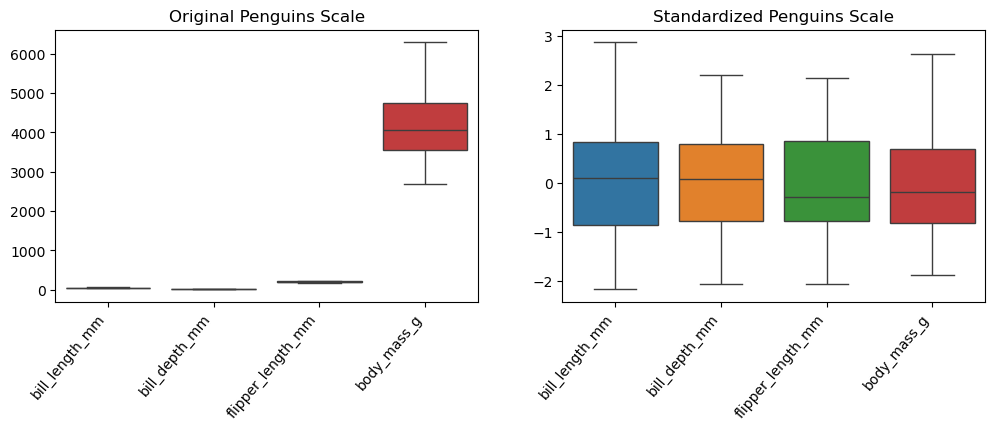

In [5]:
### visualization
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=penguins_numeric, ax=ax[0])
sns.boxplot(data=penguins_std, ax=ax[1])
ax[0].set_title('Original Penguins Scale')
ax[1].set_title('Standardized Penguins Scale')
fig.autofmt_xdate(rotation=50)
plt.show()

## **MinMax Scaling:**
This method identifies the original range of values and converts them to a new range 0 to 1.

In [6]:
scaler = MinMaxScaler()
penguins_minmax = pd.DataFrame(
    scaler.fit_transform(penguins_numeric),
    columns = penguins_numeric.columns
)

penguins_minmax.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,0.254545,0.666667,0.152542,0.291667
1,0.269091,0.511905,0.237288,0.305556
2,0.298182,0.583333,0.389831,0.152778
3,0.167273,0.738095,0.355932,0.208333
4,0.261818,0.892857,0.305085,0.263889


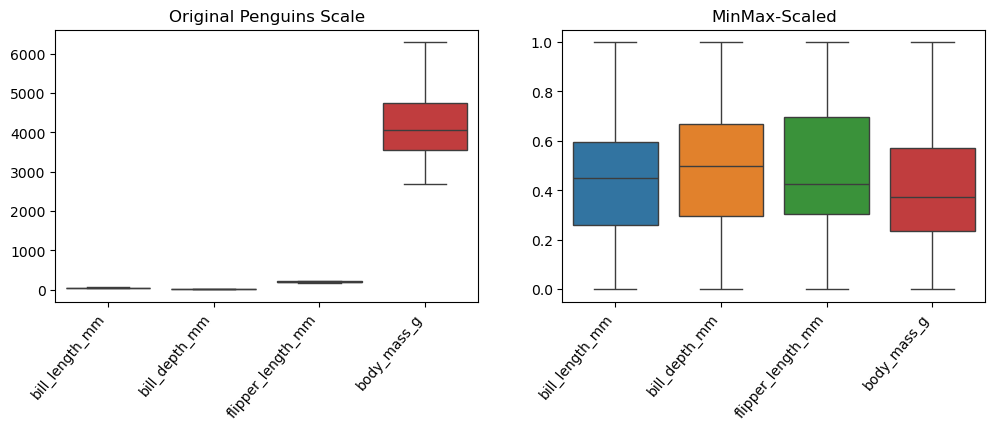

In [7]:
### visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=penguins_numeric, ax=ax[0])
sns.boxplot(data=penguins_minmax, ax=ax[1])
ax[0].set_title('Original Penguins Scale')
ax[1].set_title('MinMax-Scaled')
fig.autofmt_xdate(rotation=50)
plt.show()

## **Robust Scaling:**
Robust scaling subtracts off the second quartile of the attribute and divides by the inter-quartile range. The resulting data will be centered using the median, rather than the mean, and scaled based on the inter-quartile range rather than the range. This approach is best for data that contains outliers. 

In [8]:
scaler = RobustScaler()
penguins_robust = pd.DataFrame(
    scaler.fit_transform(penguins_numeric),
    columns = penguins_numeric.columns
)

penguins_robust.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.576819,0.451613,-0.695652,-0.250000
1,-0.533693,0.032258,-0.478261,-0.208333
2,-0.447439,0.225806,-0.086957,-0.666667
3,-0.835580,0.645161,-0.173913,-0.500000
4,-0.555256,1.064516,-0.304348,-0.333333


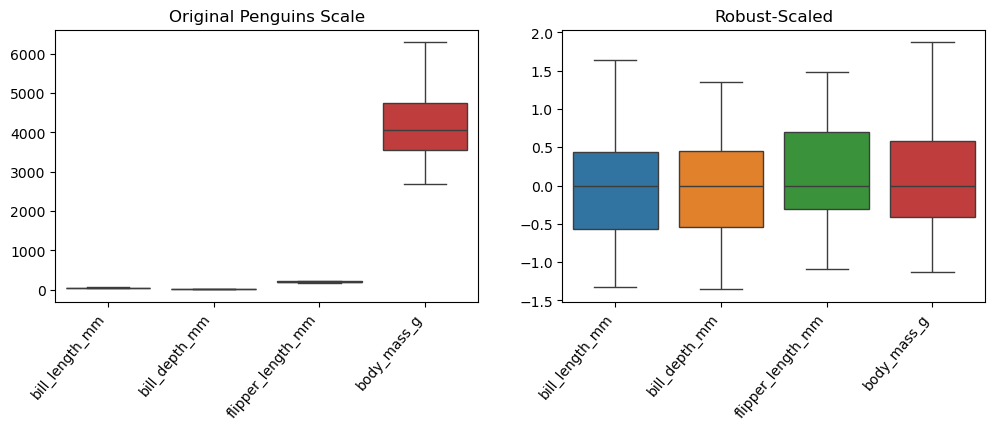

In [9]:
### visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=penguins_numeric, ax=ax[0])
sns.boxplot(data=penguins_robust, ax=ax[1])
ax[0].set_title('Original Penguins Scale')
ax[1].set_title('Robust-Scaled')
fig.autofmt_xdate(rotation=50)
plt.show()

### **Notes & Misc.**

##### It is important to note that standardization/scaling should not change the distribution of the data.
##### for example, distribution of flipper_length_mm original data vs Robust-Scaled:

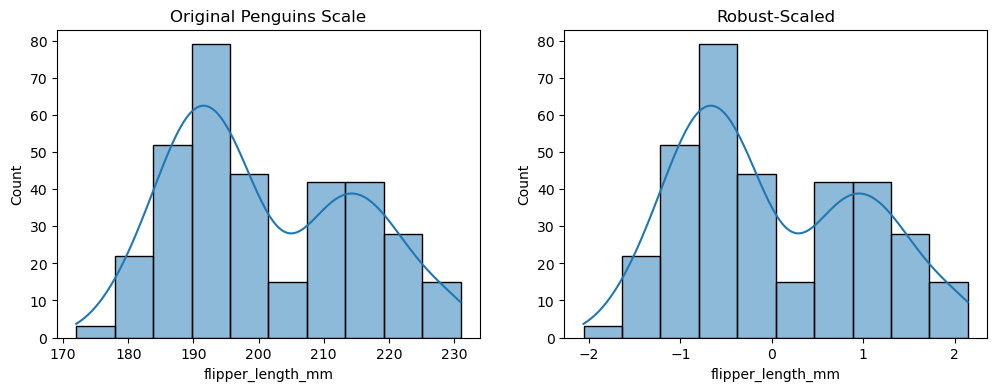

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=penguins_numeric, x='flipper_length_mm', kde=True, ax=ax[0])
sns.histplot(data=penguins_std, x='flipper_length_mm', kde=True, ax=ax[1])
ax[0].set_title('Original Penguins Scale')
ax[1].set_title('Robust-Scaled')
plt.show()

In [11]:
### you can add your categorical variables back into your standardized dataset by a join
df = penguins_std.join(penguins[['island', 'sex']])
df.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island,sex
0,-0.884499,0.785449,-1.418347,-0.564142,Torgersen,Male
1,-0.811126,0.126188,-1.062250,-0.501703,Torgersen,Female
2,-0.664380,0.430462,-0.421277,-1.188532,Torgersen,Female
3,-1.324737,1.089724,-0.563715,-0.938776,Torgersen,NaN
4,-0.847812,1.748985,-0.777373,-0.689020,Torgersen,Female
